# CWRU Spectrogram Augmentation Figure Generator

이 노트북은 이미 생성된 spectrogram 이미지 데이터셋을 불러와서, 보고서에 넣기 좋은 **Original vs Augmented** 비교 figure를 만듭니다.

목적은 다음과 같습니다.

1. 원본 spectrogram 이미지가 어떤 모습인지 보여주기
2. `RandomAffine`, `Brightness/Contrast`, `RandomErasing`이 어떤 변화를 만드는지 시각화하기
3. 논문/보고서에서 “데이터 증강을 적용했다”는 내용을 그림으로 설명하기

주의: 이 노트북은 **보고서용 시각화**를 만드는 용도입니다. 실제 학습에서는 원본 이미지를 복사해서 저장하기보다는, PyTorch `transform`으로 train loader에서 실시간 증강하는 방식을 권장합니다.

In [7]:
# 필요한 라이브러리
# 처음 실행하는 환경에서 에러가 나면 아래 주석을 해제해서 설치하면 된다.
# !pip install pillow matplotlib pandas torchvision

from pathlib import Path
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

try:
    import torchvision.transforms as T
    TORCHVISION_AVAILABLE = True
except Exception as e:
    TORCHVISION_AVAILABLE = False
    print('torchvision import failed:', e)

print('torchvision available:', TORCHVISION_AVAILABLE)

torchvision available: True


## 1. 경로 설정

`DATASET_ROOT`는 `02_make_training_dataset_sliding.ipynb`로 만든 결과 폴더를 가리키면 됩니다.

기본 구조는 아래와 같습니다.

```text
cwru_spectrogram_training_dataset/
├─ dataset_images/
│  ├─ Fault_BALL_007/
│  ├─ Fault_IR_014/
│  └─ Normal/
└─ metadata.csv
```

In [8]:
DATASET_ROOT = Path('./cwru_spectrogram_training_dataset')
IMAGE_ROOT = DATASET_ROOT / 'dataset_images'
SAVE_DIR = DATASET_ROOT / 'augmentation_figures'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('IMAGE_ROOT:', IMAGE_ROOT.resolve())
print('SAVE_DIR:', SAVE_DIR.resolve())

IMAGE_ROOT: C:\Users\한동현\OneDrive - 중앙대학교\기계인공지능_프로젝트_코드_데이터\cwru_spectrogram_notebooks\cwru_notebook_files\cwru_spectrogram_training_dataset\dataset_images
SAVE_DIR: C:\Users\한동현\OneDrive - 중앙대학교\기계인공지능_프로젝트_코드_데이터\cwru_spectrogram_notebooks\cwru_notebook_files\cwru_spectrogram_training_dataset\augmentation_figures


## 2. 증강 함수 정의

여기서는 보고서 figure에 보여주기 좋은 대표 증강을 만듭니다.

- `Affine`: 미세한 회전, 이동, 확대/축소
- `Brightness/Contrast`: 밝기와 대비 변화
- `Random Erasing`: 일부 영역 제거
- `Combined`: 여러 증강을 섞은 예시

In [9]:
def random_erasing_pil(img, p=1.0, scale=(0.03, 0.12), ratio=(0.3, 3.3), fill=0):
    """PIL 이미지에 Random Erasing과 비슷한 효과를 적용한다."""
    if random.random() > p:
        return img

    img = img.copy().convert('RGB')
    w, h = img.size
    area = w * h

    for _ in range(20):
        target_area = random.uniform(*scale) * area
        aspect_ratio = random.uniform(*ratio)
        erase_w = int(round((target_area * aspect_ratio) ** 0.5))
        erase_h = int(round((target_area / aspect_ratio) ** 0.5))

        if erase_w < w and erase_h < h:
            x1 = random.randint(0, w - erase_w)
            y1 = random.randint(0, h - erase_h)
            draw = ImageDraw.Draw(img)
            draw.rectangle([x1, y1, x1 + erase_w, y1 + erase_h], fill=(fill, fill, fill))
            return img

    return img


def build_augmented_versions(img, seed=None):
    """원본 이미지 1장에 대해 Original + 여러 증강 예시를 반환한다."""
    if seed is not None:
        random.seed(seed)

    img = img.convert('RGB')

    if not TORCHVISION_AVAILABLE:
        return {'Original': img}

    affine = T.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05))
    jitter = T.ColorJitter(brightness=0.25, contrast=0.35)
    combined = T.Compose([
        T.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        T.ColorJitter(brightness=0.25, contrast=0.35),
    ])

    versions = {
        'Original': img,
        'Affine': affine(img),
        'Brightness/Contrast': jitter(img),
        'Random Erasing': random_erasing_pil(img, p=1.0),
        'Combined 1': random_erasing_pil(combined(img), p=0.8),
    }
    return versions


def save_augmentation_grid(image_path, save_path, title='Spectrogram augmentation examples'):
    img = Image.open(image_path)
    versions = build_augmented_versions(img)

    n = len(versions)
    fig, axes = plt.subplots(1, n, figsize=(3.0 * n, 3.4), dpi=200)
    if n == 1:
        axes = [axes]

    for ax, (name, im) in zip(axes, versions.items()):
        ax.imshow(im, cmap='gray')
        ax.set_title(name, fontsize=10)
        ax.axis('off')

    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches='tight')
    plt.close(fig)
    return save_path


## 3. 단일 이미지로 증강 예시 만들기

아래 셀은 데이터셋 안에서 첫 번째 이미지를 자동으로 찾아서, 원본과 증강 예시를 한 장의 figure로 저장합니다.

Number of images found: 9438
Sample image: cwru_spectrogram_training_dataset\dataset_images\Fault_BALL_007\Fault_BALL_007_1__seg00000__start0.png
Saved: cwru_spectrogram_training_dataset\augmentation_figures\augmentation_preview_single_sample.png


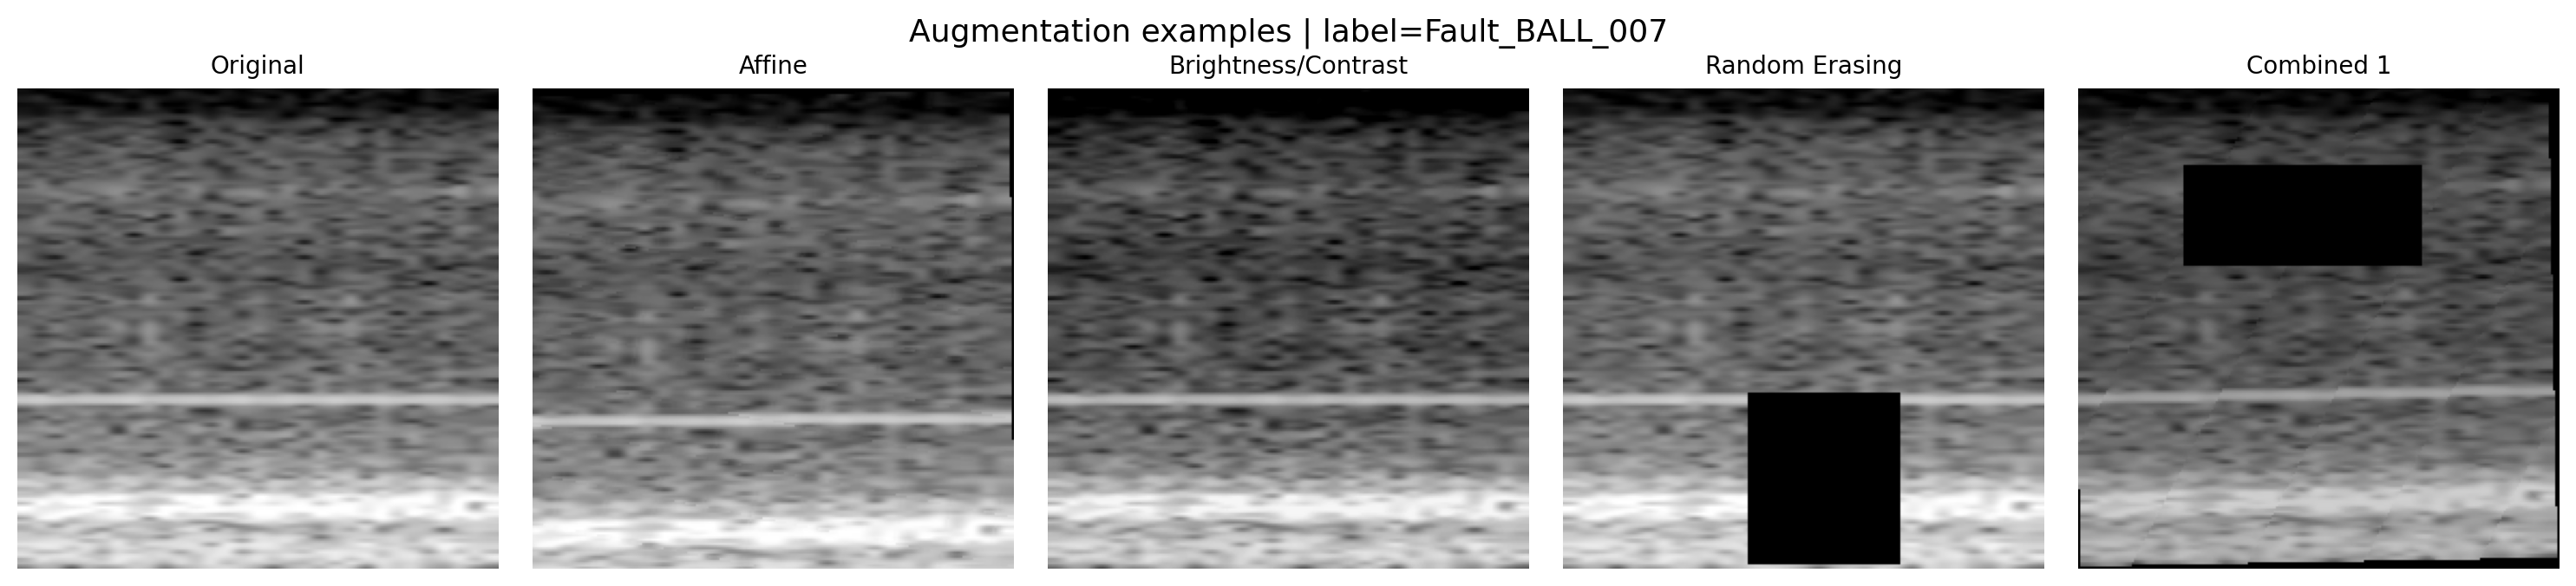

In [10]:
all_images = sorted(IMAGE_ROOT.glob('*/*.png'))
print('Number of images found:', len(all_images))

if len(all_images) == 0:
    raise FileNotFoundError('dataset_images/*/*.png 파일을 찾지 못했습니다. 02번 데이터셋 생성 노트북을 먼저 실행하세요.')

sample_image = all_images[0]
print('Sample image:', sample_image)

save_path = SAVE_DIR / 'augmentation_preview_single_sample.png'
save_augmentation_grid(
    sample_image,
    save_path,
    title=f'Augmentation examples | label={sample_image.parent.name}'
)

print('Saved:', save_path)
Image.open(save_path)


## 4. 각 클래스별 augmentation figure 생성

보고서에 넣을 때는 모든 클래스가 필요 없을 수도 있지만, 아래 코드는 각 class 폴더에서 대표 이미지 1장을 골라 augmentation preview를 저장합니다.

In [11]:
created = []

for label_dir in sorted([p for p in IMAGE_ROOT.iterdir() if p.is_dir()]):
    png_files = sorted(label_dir.glob('*.png'))
    if not png_files:
        continue

    image_path = png_files[0]
    save_path = SAVE_DIR / f'augmentation_preview_{label_dir.name}.png'
    save_augmentation_grid(
        image_path,
        save_path,
        title=f'Augmentation examples | label={label_dir.name}'
    )
    created.append(save_path)

print(f'Saved {len(created)} augmentation figures.')
for p in created:
    print(p)


Saved 10 augmentation figures.
cwru_spectrogram_training_dataset\augmentation_figures\augmentation_preview_Fault_BALL_007.png
cwru_spectrogram_training_dataset\augmentation_figures\augmentation_preview_Fault_BALL_014.png
cwru_spectrogram_training_dataset\augmentation_figures\augmentation_preview_Fault_BALL_021.png
cwru_spectrogram_training_dataset\augmentation_figures\augmentation_preview_Fault_IR_007.png
cwru_spectrogram_training_dataset\augmentation_figures\augmentation_preview_Fault_IR_014.png
cwru_spectrogram_training_dataset\augmentation_figures\augmentation_preview_Fault_IR_021.png
cwru_spectrogram_training_dataset\augmentation_figures\augmentation_preview_Fault_OR_007.png
cwru_spectrogram_training_dataset\augmentation_figures\augmentation_preview_Fault_OR_014.png
cwru_spectrogram_training_dataset\augmentation_figures\augmentation_preview_Fault_OR_021.png
cwru_spectrogram_training_dataset\augmentation_figures\augmentation_preview_Normal.png


## 5. 논문/보고서용 문장 예시

아래 문장을 보고서에 그대로 응용할 수 있습니다.

> 본 연구에서는 제한된 CWRU 진동 신호 데이터를 효과적으로 활용하기 위해 sliding window 기반 spectrogram 생성을 수행하였다. 또한 모델 학습 과정에서는 미세한 affine 변환, 밝기/대비 변화, random erasing을 적용하여 센서 신호의 측정 조건 변화와 이미지화 과정에서 발생할 수 있는 작은 변동에 대해 모델이 강건하게 학습하도록 구성하였다. Figure X는 원본 spectrogram과 적용된 데이터 증강 예시를 보여준다.

## 6. 학습 코드에 들어갈 train transform 예시

실제 학습에서는 아래처럼 train transform에만 증강을 넣고, validation/test에는 넣지 않는 것을 권장합니다.

In [12]:
# 학습 코드에 넣을 수 있는 transform 예시
# RGB pretrained 모델을 쓸 경우 Grayscale(num_output_channels=3)을 사용하면 된다.

if TORCHVISION_AVAILABLE:
    IMG_SIZE = 224

    train_transform = T.Compose([
        T.Grayscale(num_output_channels=3),
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.RandomApply([
            T.RandomAffine(
                degrees=5,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05)
            )
        ], p=0.7),
        T.RandomApply([
            T.ColorJitter(brightness=0.15, contrast=0.20)
        ], p=0.5),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]),
        T.RandomErasing(p=0.15, scale=(0.02, 0.08), ratio=(0.3, 3.3))
    ])

    eval_transform = T.Compose([
        T.Grayscale(num_output_channels=3),
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])

    print(train_transform)
else:
    print('torchvision이 없어서 transform 예시를 만들 수 없습니다.')


Compose(
    Grayscale(num_output_channels=3)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomApply(
    p=0.7
    RandomAffine(degrees=[-5.0, 5.0], translate=(0.05, 0.05), scale=(0.95, 1.05))
)
    RandomApply(
    p=0.5
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.8, 1.2), saturation=None, hue=None)
)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    RandomErasing(p=0.15, scale=(0.02, 0.08), ratio=(0.3, 3.3), value=0, inplace=False)
)
